# Análisis espacial de humedales de Bogotá
Este Notebook carga, revisa y visualiza capas geográficas relacionadas con los humedales de Bogotá.

# Importación de Bibliotecas

In [4]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("GeoPandas:", gpd.__version__)

GeoPandas: 1.1.3


# Rutas del Proyecto

In [5]:
ROOT = Path("..")

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_EXPORTS = ROOT / "data" / "exports"

print("Raw:", DATA_RAW.resolve())
print("Processed:", DATA_PROCESSED.resolve())
print("Exports:", DATA_EXPORTS.resolve())

Raw: D:\00_Portafolio\humedales\data\raw
Processed: D:\00_Portafolio\humedales\data\processed
Exports: D:\00_Portafolio\humedales\data\exports


In [6]:
for archivo in DATA_RAW.rglob("*"):
    print(archivo.name)

.gitkeep
bogota.zip
cober_vege_humedales.zip
mallavialintermedia.zip
pensionadosupz_042023.zip
proyecciones-bogota-UPZ.xlsx
RUNAP.zip
suelo.zip


In [7]:
zip_files=list(DATA_RAW.glob("*.zip"))

for i, archivo in enumerate(zip_files):
    print(f"{i}: {archivo.name}")

0: bogota.zip
1: cober_vege_humedales.zip
2: mallavialintermedia.zip
3: pensionadosupz_042023.zip
4: RUNAP.zip
5: suelo.zip


In [8]:
import zipfile
zip_path = zip_files[1]
with zipfile.ZipFile(zip_path, "r") as z:
    for nombre in z.namelist():
        print(nombre)

#Con base en lo que ponga en el indice ese es el que se plotea.

Cober_vege_humedales.CPG
Cober_vege_humedales.dbf
Cober_vege_humedales.prj
Cober_vege_humedales.sbn
Cober_vege_humedales.sbx
Cober_vege_humedales.shp
Cober_vege_humedales.shp.xml
Cober_vege_humedales.shx


In [9]:
humedales = gpd.read_file(f"zip://{zip_path}")
humedales.head(18)

,id,cobertura,periodo,fechaini,fechafin,nombre,Shape_Leng,Shape_Area,geometry
0,0,Espejo de Agua,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.008408,2.909491e-06,"POLYGON ((-74.08022 4.70559, -74.08022 4.70558..."
1,0,Areas Endurecidas,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001286,5.918345e-08,"POLYGON ((-74.06448 4.70941, -74.06495 4.70962..."
2,0,Areas Endurecidas,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.000976,2.471359e-08,"POLYGON ((-74.06263 4.71131, -74.06278 4.71134..."
3,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001068,3.993026e-08,"POLYGON ((-74.06268 4.71007, -74.06269 4.71004..."
4,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.002615,1.979630e-07,"POLYGON ((-74.08152 4.70303, -74.08158 4.70305..."
5,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.006536,2.788910e-07,"POLYGON ((-74.08126 4.70488, -74.08126 4.70487..."
6,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.007849,4.226233e-07,"POLYGON ((-74.08097 4.70263, -74.0811 4.70212,..."
7,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.010903,1.017595e-06,"POLYGON ((-74.08171 4.70487, -74.08154 4.70432..."
8,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001661,8.070063e-08,"POLYGON ((-74.08241 4.70395, -74.08245 4.70405..."
9,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.002820,7.773051e-08,"POLYGON ((-74.06544 4.70961, -74.06545 4.70957..."


In [10]:
#Para verificar que el nombre del humedal es correcto, se puede usar el siguiente código:
humedales["nombre"].unique()

<StringArray>
[           'Humedal de Cordoba y Niza',
          'Humedal del Meandro del Say',
                  'Humedal del Salitre',
 'Humedal de Juan Amarillo o Tibabuyes',
               'Humedal de la Conejera',
                 'Humedal de Guaymaral',
                   'Humedal de La Isla',
                   'Humedal de Jaboque',
     'Humedal de Capellania o Cofradia',
      'Humedal de Santa María del Lago',
                     'Humedal de Techo',
                  'Humedal de Tibanica',
                    'Humedal del Burro',
                   'Humedal de La Vaca',
                     'Humedal el Tunjo']
Length: 15, dtype: str

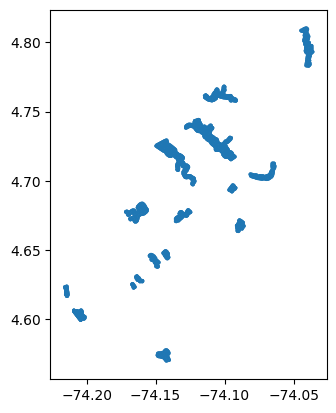

In [11]:
humedales.plot()
plt.show()

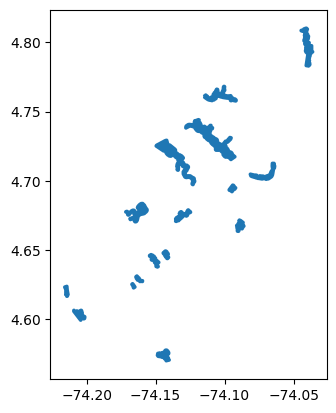

In [12]:
humedales_boundary = humedales.dissolve(by="nombre").reset_index()
humedales_boundary.head(18)
humedales_boundary.plot()
plt.show()

In [13]:
print("Registros capa original:", len(humedales))
print("Registros después del dissolve:", len(humedales_boundary))

Registros capa original: 7112
Registros después del dissolve: 15


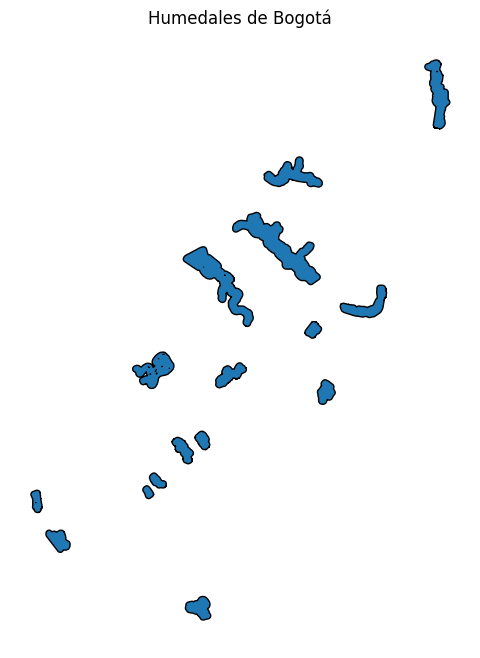

In [14]:
ax = humedales_boundary.plot(
    figsize=(10, 8),
    edgecolor="black"
)

ax.set_title("Humedales de Bogotá")
ax.set_axis_off()
plt.show()

## Guardar el resultado procesado

In [15]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_EXPORTS.mkdir(parents=True, exist_ok=True)

humedales_boundary.to_file(
    DATA_PROCESSED / "humedales_boundary.gpkg",
    driver="GPKG"
)

humedales_boundary.to_file(
    DATA_EXPORTS / "humedales_boundary.geojson",
    driver="GeoJSON"
)

print("Boundary exportado correctamente.")

Boundary exportado correctamente.


In [16]:
# Revisar geometrías válidas
humedales_boundary["geometry_valid"] = humedales_boundary.geometry.is_valid

humedales_boundary["geometry_valid"].value_counts()

geometry_valid
True    15
Name: count, dtype: int64

In [17]:
print("CRS de la capa:", humedales_boundary.crs)

CRS de la capa: EPSG:4686


In [18]:
humedales_boundary_projected = humedales_boundary.to_crs(epsg=3116)
print("CRS proyectado:", humedales_boundary_projected.crs)

CRS proyectado: EPSG:3116


In [19]:
humedales_boundary_projected["area_m2"] = humedales_boundary_projected.geometry.area
humedales_boundary_projected["area_ha"] = humedales_boundary_projected["area_m2"] / 10000

humedales_boundary_projected[["nombre", "area_m2", "area_ha"]].head(15)

,nombre,area_m2,area_ha
0,Humedal de Capellania o Cofradia,8.969456e+05,89.694556
1,Humedal de Cordoba y Niza,1.349439e+06,134.943920
2,Humedal de Guaymaral,1.953905e+06,195.390541
3,Humedal de Jaboque,3.518984e+06,351.898449
4,Humedal de Juan Amarillo o Tibabuyes,4.377453e+06,437.745342
5,Humedal de La Isla,4.129495e+05,41.294946
6,Humedal de La Vaca,5.597199e+05,55.971993
7,Humedal de Santa María del Lago,4.048163e+05,40.481631
8,Humedal de Techo,4.223386e+05,42.233858
9,Humedal de Tibanica,7.768518e+05,77.685176


In [20]:
areas_humedales = humedales_boundary_projected[
    ["nombre", "area_m2", "area_ha"]
].sort_values("area_ha", ascending=False)
areas_humedales


,nombre,area_m2,area_ha
4,Humedal de Juan Amarillo o Tibabuyes,4.377453e+06,437.745342
3,Humedal de Jaboque,3.518984e+06,351.898449
2,Humedal de Guaymaral,1.953905e+06,195.390541
10,Humedal de la Conejera,1.868131e+06,186.813143
12,Humedal del Meandro del Say,1.787447e+06,178.744739
1,Humedal de Cordoba y Niza,1.349439e+06,134.943920
0,Humedal de Capellania o Cofradia,8.969456e+05,89.694556
14,Humedal el Tunjo,8.844191e+05,88.441915
9,Humedal de Tibanica,7.768518e+05,77.685176
11,Humedal del Burro,6.838264e+05,68.382641


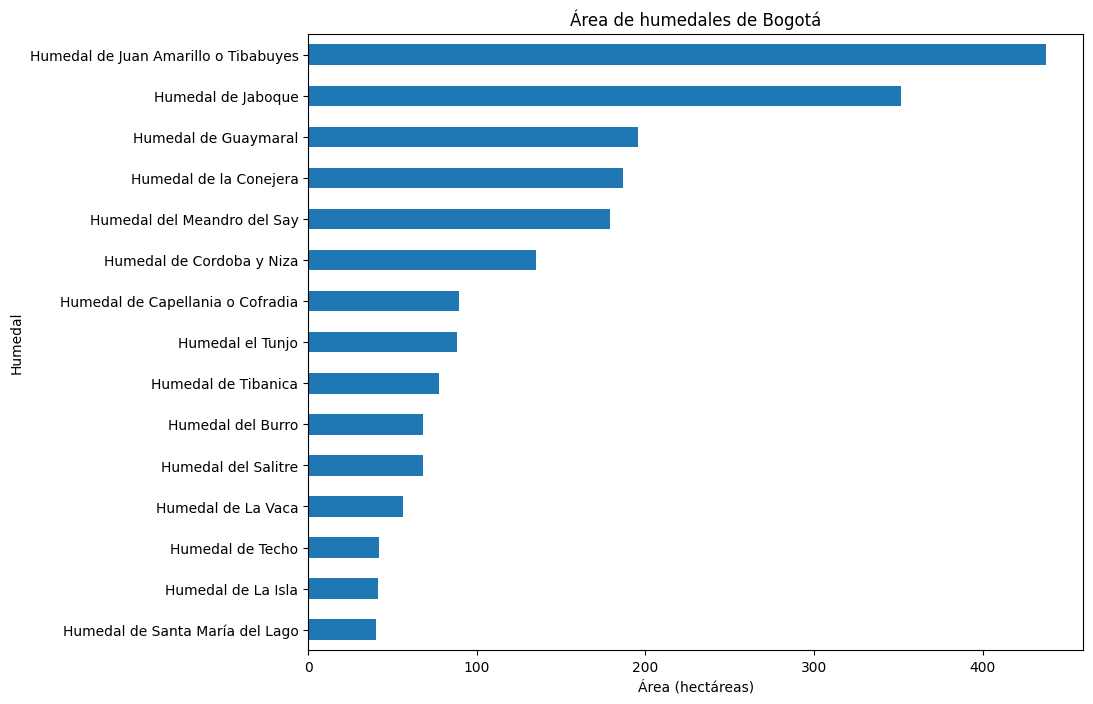

In [21]:
ax = areas_humedales.plot(
    kind="barh",
    x="nombre",
    y="area_ha",
    figsize=(10, 8),
    legend=False
)

ax.set_title("Área de humedales de Bogotá")
ax.set_xlabel("Área (hectáreas)")
ax.set_ylabel("Humedal")
plt.gca().invert_yaxis()
plt.show()

In [22]:
#Exportar resultados a CSV
areas_humedales.to_csv(
    DATA_EXPORTS / "areas_humedales.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabla exportada:", DATA_EXPORTS / "areas_humedales.csv")

Tabla exportada: ..\data\exports\areas_humedales.csv


In [23]:
humedales_boundary_projected.to_file(
    DATA_PROCESSED / "humedales_boundary_area.gpkg",
    layer="humedales_boundary_area",
    driver="GPKG"
)

humedales_boundary_projected.to_file(
    DATA_EXPORTS / "humedales_boundary_area.geojson",
    driver="GeoJSON"
)

print("Boundary con áreas exportado correctamente.")

Boundary con áreas exportado correctamente.


In [24]:
humedales_boundary_projected.to_crs(epsg=4326).explore(
    column="area_ha",
    tooltip=["nombre", "area_ha"],
    legend=True,
    tiles="CartoDB positron"
)